# PCA

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1702.62it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


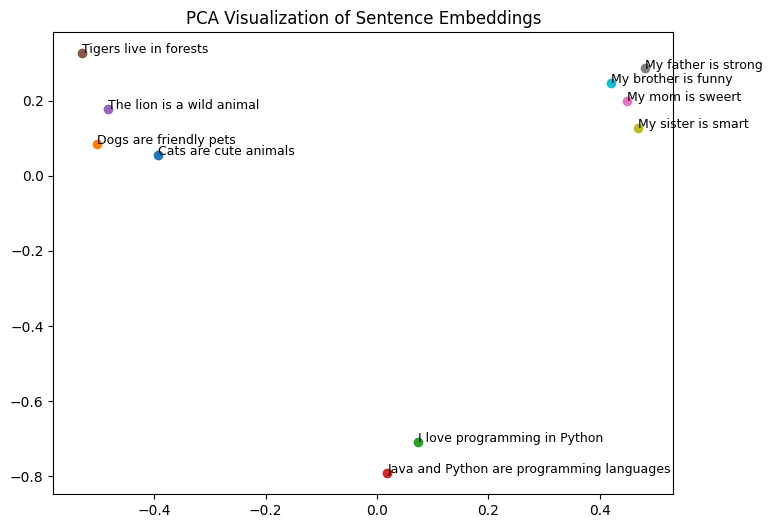

In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

# Load pre-trained model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Sample sentences
sentences = [
    "Cats are cute animals",
    "Dogs are friendly pets",
    "I love programming in Python",
    "Java and Python are programming languages",
    "The lion is a wild animal",
    "Tigers live in forests",
    "My mom is sweert",
    "My father is strong",
    "My sister is smart",
    "My brother is funny"
]

# Generate embeddings
embeddings = model.encode(sentences)

reduced_embeddings = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(8,6))

for i, sentence in enumerate(sentences):
    x, y = reduced_embeddings[i]
    plt.scatter(x, y)
    plt.text(x, y, sentence, fontsize=9)

plt.title("PCA Visualization of Sentence Embeddings")
plt.show()

# PCA vs t-SNE

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## PCA

- Some overlap between digits
- Linear separation

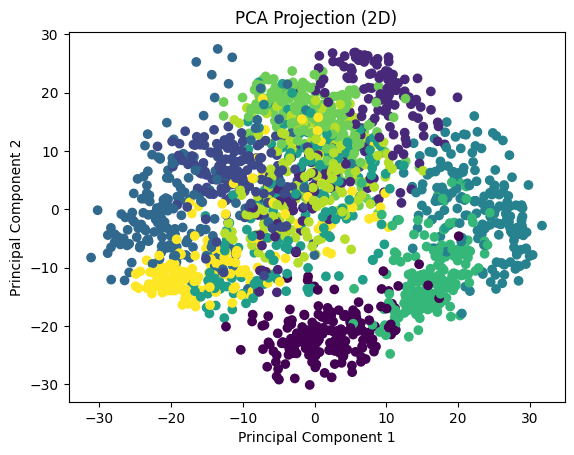

In [5]:
# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("PCA Projection (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## t-SNE

- Clear digit clusters
- Non-linear grouping
- Better local structure

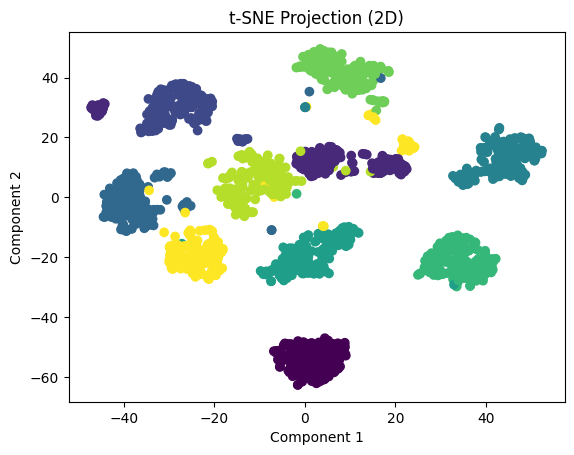

In [6]:
# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
plt.title("t-SNE Projection (2D)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()